# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

In [4]:
!pip install timm mamba-ssm -q

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# ============================================================
# 2. IMPORTS
# ============================================================

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import torch

from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 3. CONFIGURATION
# ============================================================

In [6]:
from google.colab import drive

drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/UFS - Mestrado/Visão Computacional/DataSets/chest ray-x pneumonia'

IMG_SIZE = (224,224)
BATCH_SIZE = 16
EPOCHS = 25
SEED = 42

Mounted at /content/drive


# ============================================================
# 4. LOAD DATASETS
# ============================================================

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir + "/train",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir + "/train",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 5232 files belonging to 2 classes.
Using 4186 files for training.
Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.


# ============================================================
# 5. COMPUTE CLASS WEIGHTS
# ============================================================

In [8]:
y_train = []

for images, labels in train_ds:
    y_train.extend(labels.numpy().flatten())

y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(1.9061930783242258), 1: np.float64(0.6777849740932642)}


# ============================================================
# 6. PERFORMANCE OPTIMIZATION
# ============================================================

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# ============================================================
# 7. DATA AUGMENTATION
# ============================================================

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.05),
    layers.RandomBrightness(0.1)
])

# ============================================================
# 8. BUILD DENSENET121 MODEL
# ============================================================

In [11]:
from tensorflow.keras.applications import DenseNet121

def build_densenet121():

    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    # DenseNet121 has ~427 layers (vs ResNet50's ~175).
    # Unfreezing the last ~140 layers keeps roughly the same proportion
    # as the ResNet50 setup (~last 80 of 175 ≈ last conv block).
    # This corresponds approximately to the final dense block (conv5).
    for layer in base_model.layers[:-140]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))

    x = data_augmentation(inputs)

    x = tf.keras.applications.densenet.preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        1,
        activation='sigmoid'
    )(x)

    model = tf.keras.Model(inputs, outputs)

    return model

model = build_densenet121()

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 3,434,881 (13.10 MB)

 Non-trainable params: 3,865,280 (14.74 MB)

# ============================================================
# 9. LEARNING RATE SCHEDULE
# ============================================================

In [12]:
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=steps_per_epoch * EPOCHS
)

# ============================================================
# 10. COMPILE MODEL
# ============================================================

In [13]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=lr_schedule
    ),

    loss=tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True
    ),

    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# ============================================================
# 11. CALLBACKS
# ============================================================

In [14]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/best_densenet121.keras',

    monitor='val_auc',

    mode='max',

    save_best_only=True,

    verbose=1
    )
]

# ============================================================
# 12. TRAIN MODEL
# ============================================================

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/25
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7271 - auc: 0.8637 - loss: 0.4331 - precision: 0.9329 - recall: 0.6752
Epoch 1: val_auc improved from None to 0.99175, saving model to /content/drive/MyDrive/best_densenet121.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_densenet121.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 1403s 5s/step - accuracy: 0.8189 - auc: 0.9392 - loss: 0.3701 - precision: 0.9690 - recall: 0.7795 - val_accuracy: 0.9379 - val_auc: 0.9918 - val_loss: 0.2784 - val_precision: 0.9959 - val_recall: 0.9220
Epoch 2/25
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9027 - auc: 0.9766 - loss: 0.2662 - precision: 0.9906 - recall: 0.8729
Epoch 2: val_auc improved from 0.99175 to 0.99549, saving model to /content/drive/MyDrive/best_densenet121.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_densenet121.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 1127s 4s/step - accuracy: 0.9202 - auc: 0.9825 - loss: 0.2481 - precision: 0.9939

# ============================================================
# 13. PLOT TRAINING HISTORY
# ============================================================

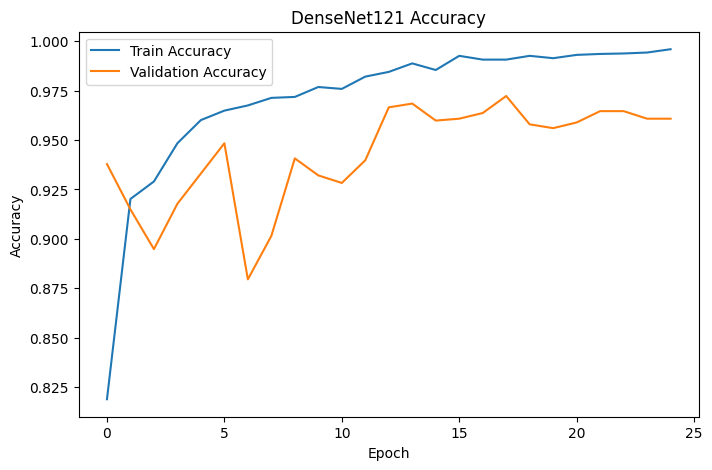

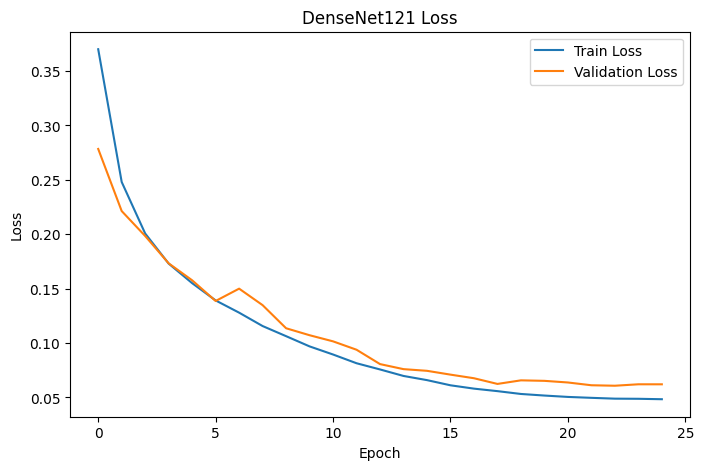

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('DenseNet121 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('DenseNet121 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

# ============================================================
# 14. TEST TIME AUGMENTATION
# ============================================================

In [17]:
def tta_predict(model, images, n=5):

    preds = []

    for _ in range(n):

        augmented = data_augmentation(
            images,
            training=True
        )

        pred = model.predict(
            augmented,
            verbose=0
        )

        preds.append(pred)

    return np.mean(preds, axis=0)

# ============================================================
# 15. GET PREDICTIONS
# ============================================================

In [18]:
def get_predictions(model, dataset):

    y_true = []
    y_pred = []

    for x, y in dataset:

        preds = tta_predict(
            model,
            x,
            n=5
        )

        y_true.extend(y.numpy())
        y_pred.extend(preds.flatten())

    return np.array(y_true), np.array(y_pred)

y_true, y_pred = get_predictions(model, test_ds)

# ============================================================
# 16. THRESHOLD OPTIMIZATION
# ============================================================

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:

    preds = (y_pred > t).astype(int)

    f1 = f1_score(y_true, preds)

    if f1 > best_f1:

        best_f1 = f1
        best_threshold = t

print("BEST THRESHOLD:", best_threshold)
print("BEST F1:", best_f1)

# ============================================================
# 17. FINAL EVALUATION
# ============================================================

In [ ]:
y_pred_bin = (
    y_pred > best_threshold
).astype(int)

print(classification_report(
    y_true,
    y_pred_bin,
    target_names=['NORMAL', 'PNEUMONIA']
))

cm = confusion_matrix(y_true, y_pred_bin)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.title('DenseNet121 Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

# ============================================================
# 18. ROC CURVE
# ============================================================

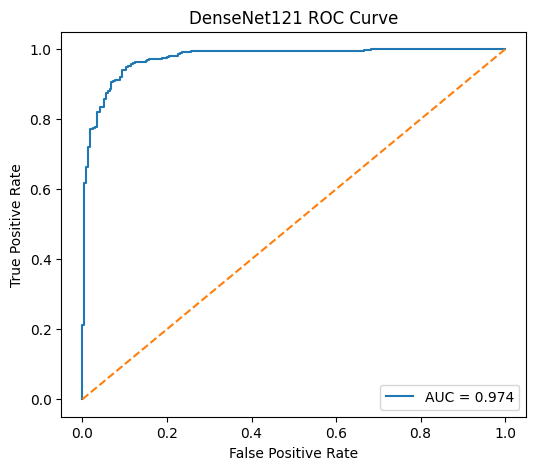

AUC SCORE: 0.9744


In [23]:
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_pred
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot([0,1], [0,1], '--')

plt.title('DenseNet121 ROC Curve')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

print(f"AUC SCORE: {roc_auc:.4f}")

# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

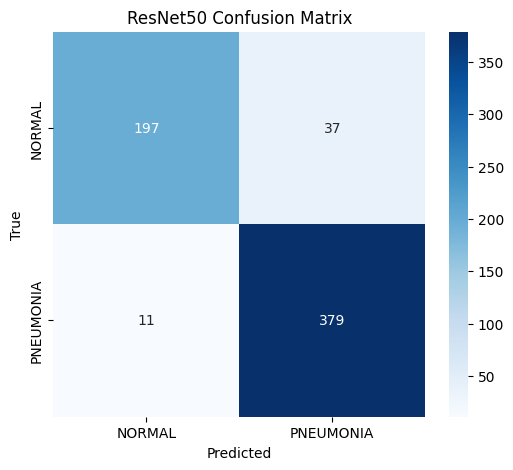

In [24]:
# ============================================================
# 21. Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_true,
    y_pred_bin
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'NORMAL',
        'PNEUMONIA'
    ],
    yticklabels=[
        'NORMAL',
        'PNEUMONIA'
    ]
)

plt.title(
    'ResNet50 Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

In [ ]:
print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true,
        y_pred_bin,
        target_names=[
            'NORMAL',
            'PNEUMONIA'
        ],
        digits=3
    )
)